<div style="text-align: center;">
    <h1 style="color: #2c3e50;">BÁO CÁO BÀI THỰC HÀNH LAB 3.1</h1>
    <h2 style="color: #34495e;">Chủ đề: So Sánh Sự Tương Đồng Của Ảnh Sử Dụng Biến Đổi Wavelet (DWT)</h2>
</div>

---

### Thông tin nhóm thực hiện:

| STT | Họ và Tên | MSSV | Vai trò/Đánh giá |
|-----|-----------|------|------------------|
| 1 | **Huỳnh Thế Hy** | 051205009083 | Nhóm trưởng |
| 2 | Nghiêm Đức Thuận | 060205003756 | Thành viên |
| 3 | Đào Thiện Nhân | 052205008343 | Thành viên |
| 4 | Tạ Nguyễn Quốc Triệu | 051205004949 | Thành viên |
| 5 | Hoàng Phú | 2251120373 | Thành viên |
| 6 | Thanh Tân | | Thành viên |

---
## I. MỤC TIÊU BÀI THỰC HÀNH

Trong bài thực hành này, mục tiêu chính là xây dựng một hệ thống so sánh sự tương đồng giữa các hình ảnh dựa trên phương pháp trích xuất đặc trưng tần số thấp. Cụ thể:

1. Tìm hiểu và ứng dụng biến đổi **Wavelet rời rạc (DWT)** để giảm chiều dữ liệu ảnh mà vẫn giữ được cấu trúc cốt lõi.
2. Xây dựng thuật toán tạo mã băm (**Image Hashing**) từ thành phần xấp xỉ của ảnh.
3. Sử dụng **khoảng cách Hamming** để định lượng mức độ sai khác giữa các chuỗi nhị phân trích xuất được.
4. Đánh giá hiệu năng của mô hình thông qua các chỉ số: **Accuracy, Recall, Specificity** và đường cong **ROC**.

## II. CƠ SỞ LÝ THUYẾT

### 1. Biến đổi Wavelet rời rạc (Discrete Wavelet Transform - DWT)
DWT phân tách ảnh thành các dải tần số khác nhau. Trong xử lý ảnh 2 chiều, một mức phân tách DWT sẽ tạo ra 4 thành phần:
- **LL (Low-Low)**: Thành phần xấp xỉ, chứa thông tin cấu trúc chính của ảnh ở tần số thấp.
- **LH, HL, HH**: Các thành phần chi tiết (ngang, dọc, chéo) chứa thông tin cạnh và nhiễu ở tần số cao.

### 2. Wavelet Hashing
Ý tưởng là sử dụng thành phần **LL** để làm đặc trưng đại diện. Vì LL ít nhạy cảm với các thay đổi nhỏ về pixel hay nhiễu, nó giúp hệ thống so sánh ổn định hơn so với việc so sánh pixel trực tiếp.

### 3. Khoảng cách Hamming (Hamming Distance)
Khoảng cách Hamming đo lường số vị trí mà tại đó các ký hiệu tương ứng của hai chuỗi có cùng độ dài là khác nhau. Trong bài này, nó dùng để đếm số bit khác biệt giữa hai mã băm ảnh.

---
## III. PHƯƠNG PHÁP VÀ THỰC HIỆN

### 3.1 Cài đặt môi trường và Cấu hình hệ thống

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pywt
import os

from matplotlib.patches import Patch
from sklearn.metrics import roc_curve, auc

# --- CÀI ĐẶT TOÀN CỤC CHO ĐỘ PHÂN GIẢI CAO ---
plt.rcParams['figure.dpi']      = 150
plt.rcParams['savefig.dpi']     = 300       
plt.rcParams['savefig.format']  = 'png'
plt.rcParams['savefig.bbox']    = 'tight'   

plt.rcParams['font.size']       = 11
plt.rcParams['axes.titlesize']  = 13
plt.rcParams['axes.labelsize']  = 11

# Thư mục lưu ảnh xuất ra để đưa vào báo cáo
OUTPUT_DIR = "../data/final_reports"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Import và cài đặt thành công!")

Import và cài đặt thành công!


### 3.2 Tiền xử lý dữ liệu ảnh đầu vào

Dữ liệu được chuẩn hóa về mức xám và kích thước 128x128 để đảm bảo tính đồng nhất khi thực hiện DWT.

In [2]:
SIZE = 128

def load_and_preprocess(filepath):
    img = cv2.imread(filepath)
    if img is None:
        raise FileNotFoundError(f"Không tìm thấy file: {filepath}")
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (SIZE, SIZE))
    return resized

def load_color(filepath):
    img = cv2.imread(filepath)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

similar1   = load_and_preprocess("../data/input/similar1.jpg")
similar2   = load_and_preprocess("../data/input/similar2.jpg")
different1 = load_and_preprocess("../data/input/different1.jpg")
different2 = load_and_preprocess("../data/input/different2.jpg")

similar1_rgb   = load_color("../data/input/similar1.jpg")
similar2_rgb   = load_color("../data/input/similar2.jpg")
different1_rgb = load_color("../data/input/different1.jpg")
different2_rgb = load_color("../data/input/different2.jpg")

print(f"Đọc ảnh thành công! Kích thước xử lý: {similar1.shape}")

Đọc ảnh thành công! Kích thước xử lý: (128, 128)


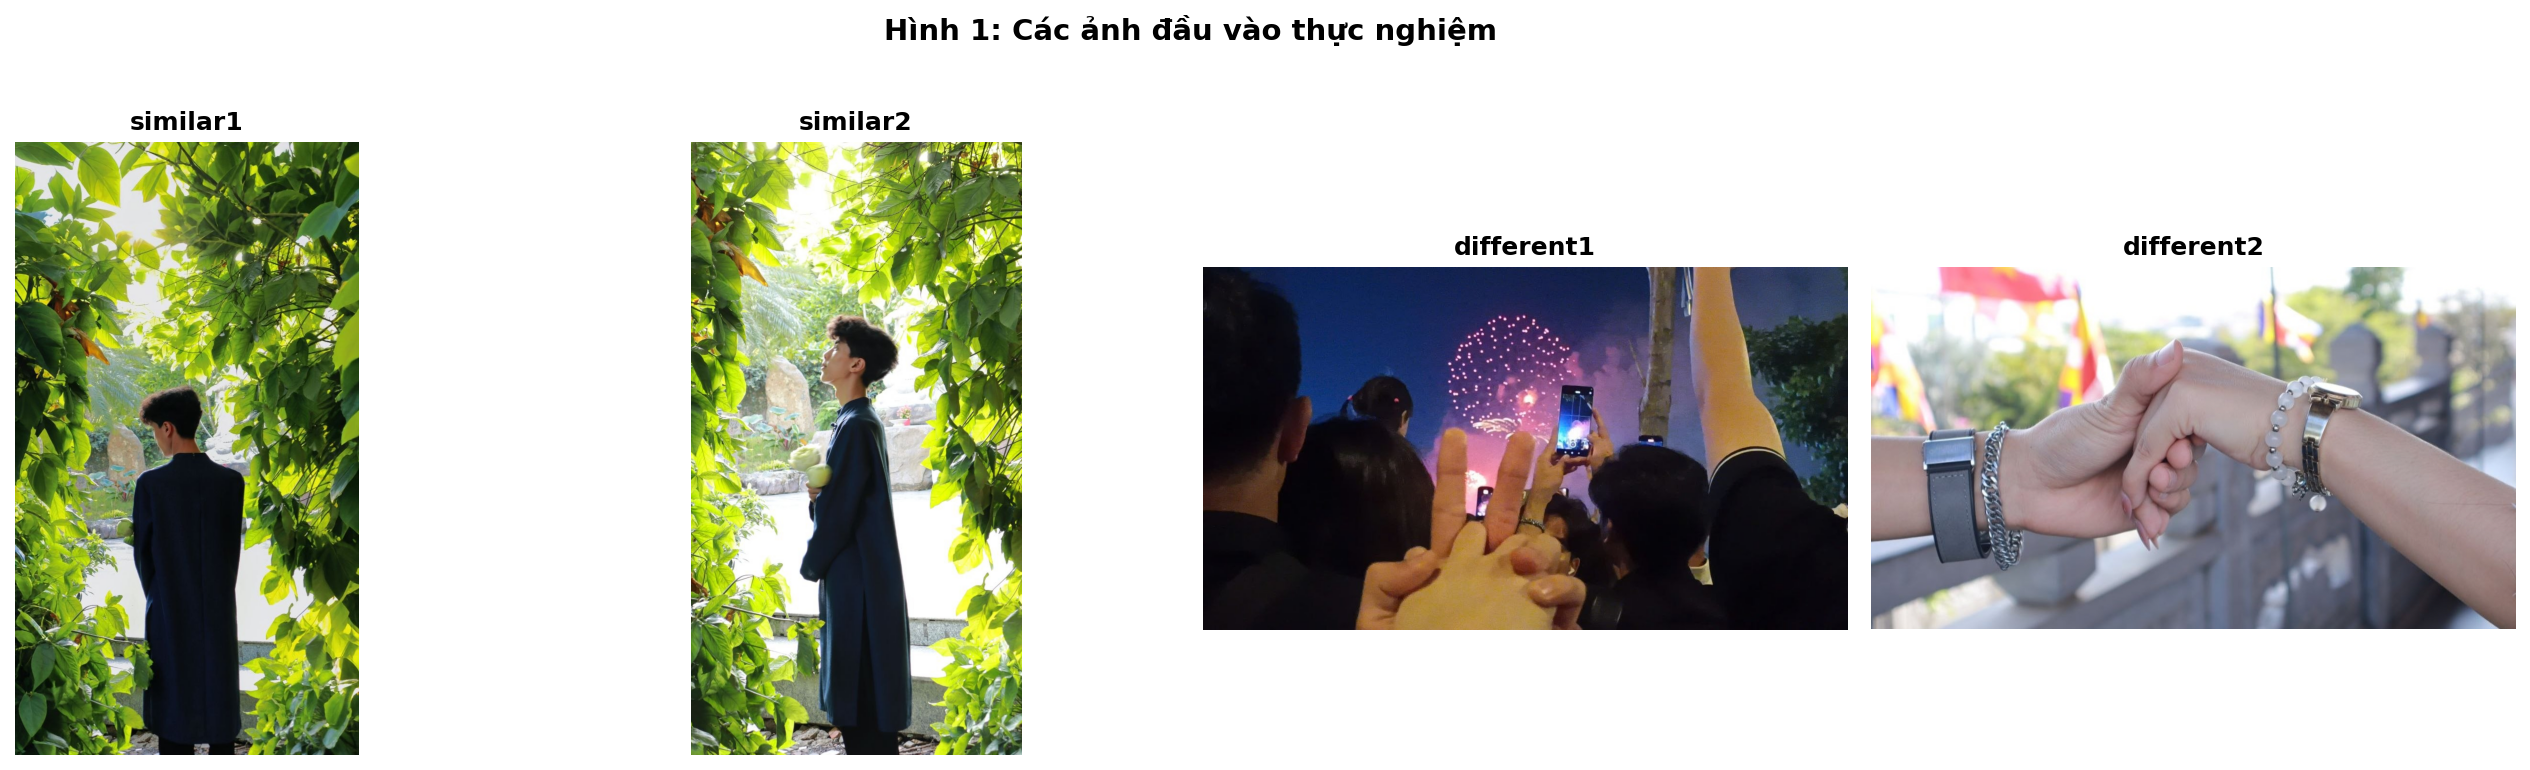

In [3]:
# Hiển thị 4 ảnh gốc minh họa
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
color_imgs = [similar1_rgb, similar2_rgb, different1_rgb, different2_rgb]
titles     = ["similar1", "similar2", "different1", "different2"]
border_colors = ["#27ae60", "#27ae60", "#e74c3c", "#e74c3c"]

for ax, img, title, bc in zip(axes, color_imgs, titles, border_colors):
    ax.imshow(img)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_edgecolor(bc); spine.set_linewidth(3)

plt.suptitle("Hình 1: Các ảnh đầu vào thực nghiệm", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hinh1_anh_goc.png")
plt.show()

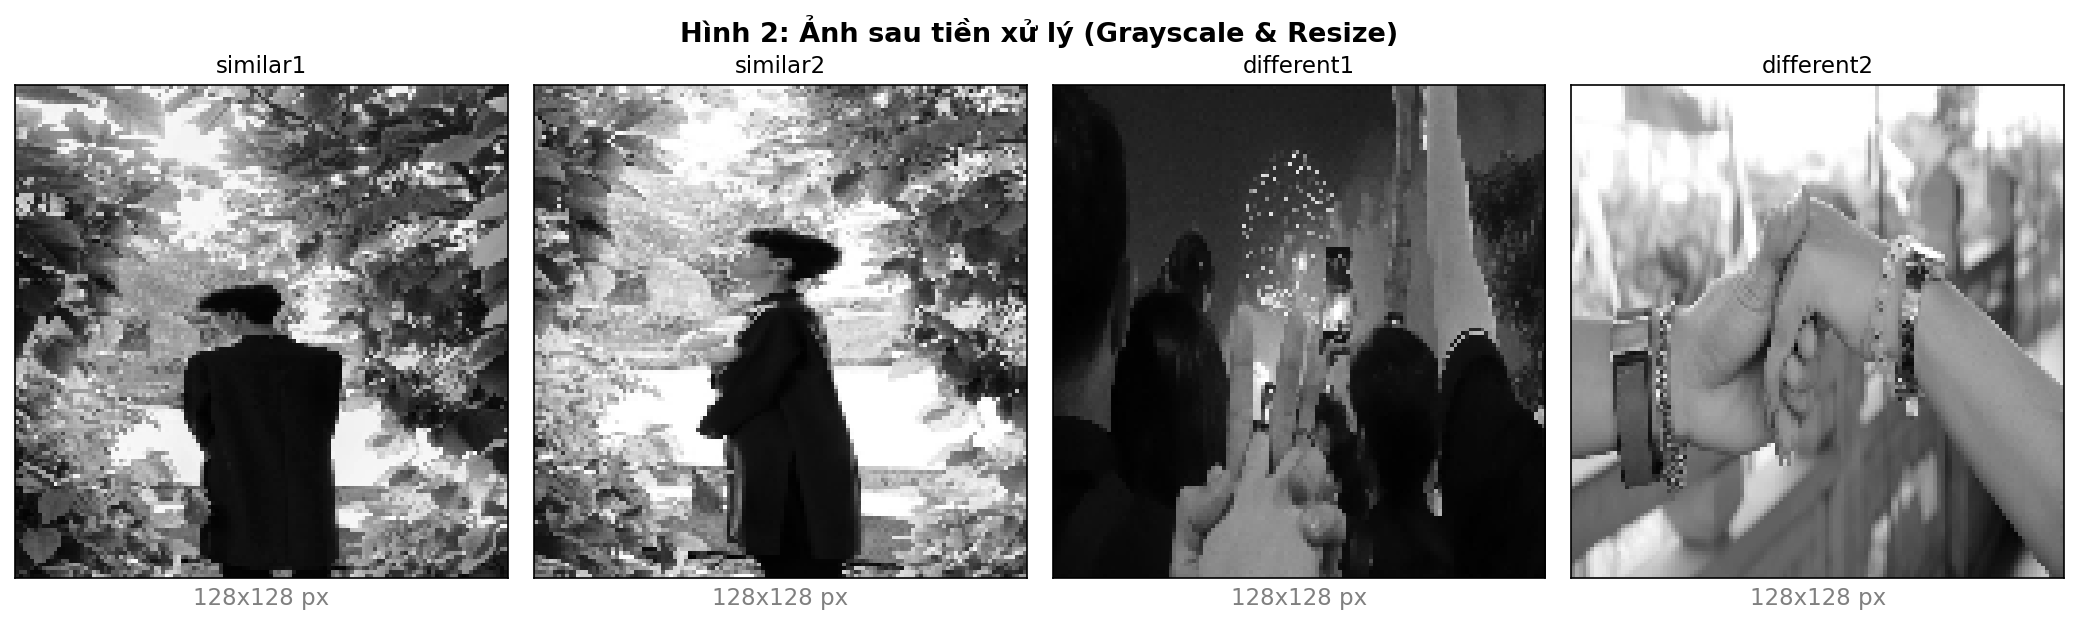

In [4]:
# Hiển thị ảnh sau tiền xử lý
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
gray_imgs = [similar1, similar2, different1, different2]

for ax, img, title, bc in zip(axes, gray_imgs, titles, border_colors):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(f"{img.shape[1]}x{img.shape[0]} px", color='gray')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Hình 2: Ảnh sau tiền xử lý (Grayscale & Resize)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hinh2_anh_grayscale.png")
plt.show()

### 3.3 Trích xuất đặc trưng Wavelet (DWT)

Sử dụng Wavelet Haar mức 1 để phân tách ảnh. Chúng ta quan tâm nhất đến thành phần LL (Approximation).

In [5]:
def apply_dwt(image, wavelet='haar'):
    coeffs2 = pywt.dwt2(image.astype(np.float64), wavelet)
    LL, (LH, HL, HH) = coeffs2
    return LL, LH, HL, HH

LL1, LH1, HL1, HH1 = apply_dwt(similar1)
LL2, LH2, HL2, HH2 = apply_dwt(similar2)
LL3, LH3, HL3, HH3 = apply_dwt(different1)
LL4, LH4, HL4, HH4 = apply_dwt(different2)

print(f"Biến đổi DWT thành công! Kích thước LL: {LL1.shape}")

Biến đổi DWT thành công! Kích thước LL: (64, 64)


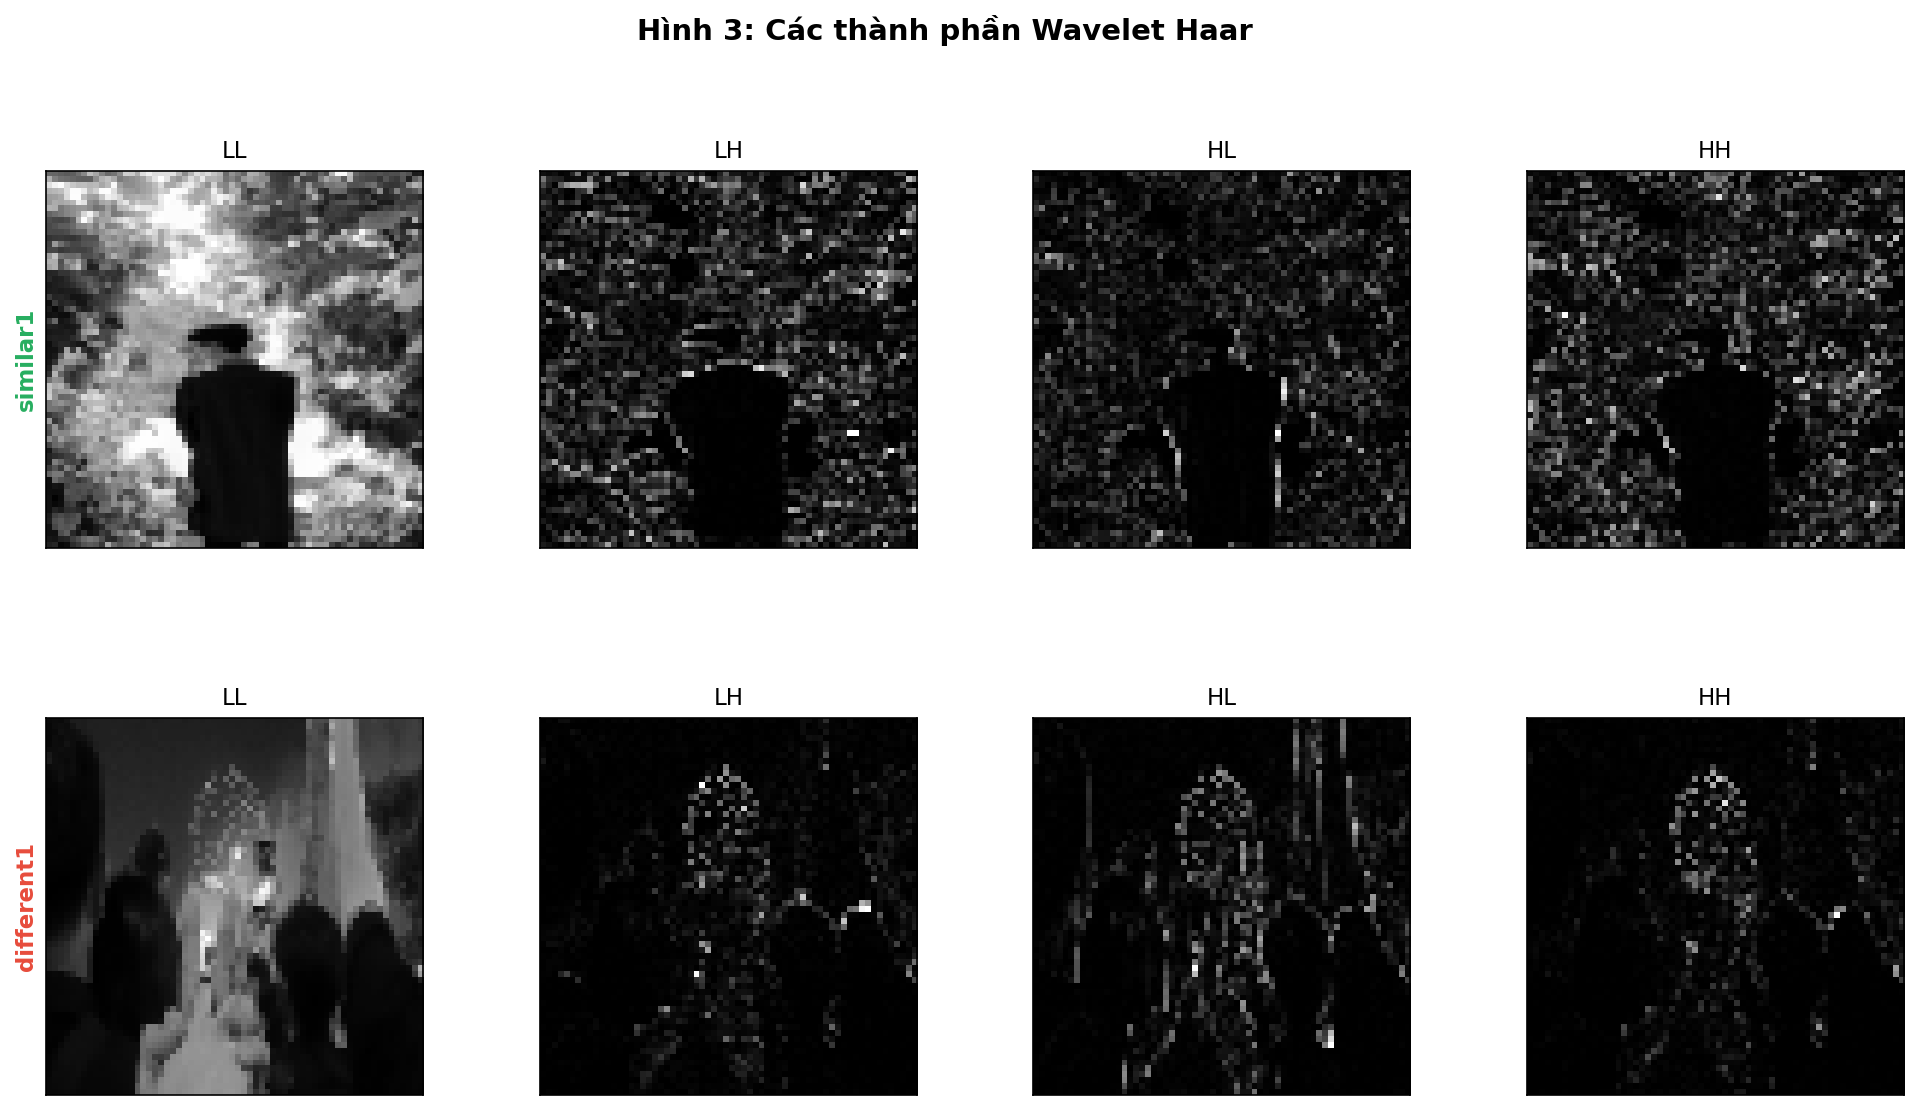

In [6]:
# Minh họa các thành phần Wavelet
fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.3)
row_data = [("similar1", [LL1, LH1, HL1, HH1], "#27ae60"), ("different1", [LL3, LH3, HL3, HH3], "#e74c3c")]
comp_names = ["LL", "LH", "HL", "HH"]

for row_idx, (img_name, comps, color) in enumerate(row_data):
    for col_idx, (comp, cname) in enumerate(zip(comps, comp_names)):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        disp = np.abs(comp) if col_idx > 0 else comp
        ax.imshow(disp, cmap='gray')
        ax.set_title(f"{cname}", fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        if col_idx == 0: ax.set_ylabel(img_name, color=color, fontweight='bold')

plt.suptitle("Hình 3: Các thành phần Wavelet Haar", fontsize=14, fontweight='bold', y=1.01)
plt.savefig(f"{OUTPUT_DIR}/hinh3_wavelet_components.png")
plt.show()

### 3.4 Thuật toán Wavelet Hash

Quy trình: LL Matrix -> Chuẩn hóa [0,1] -> Binarization (theo giá trị trung bình) -> Flatten thành Hash String.

In [7]:
def wavelet_hash(image, wavelet='haar'):
    LL, _, _, _ = apply_dwt(image, wavelet)
    ll_min, ll_max = LL.min(), LL.max()
    LL_norm = (LL - ll_min) / (ll_max - ll_min) if (ll_max - ll_min) != 0 else np.zeros_like(LL)
    mean_val    = LL_norm.mean()
    hash_matrix = (LL_norm > mean_val).astype(np.uint8)
    return hash_matrix.flatten(), hash_matrix, LL_norm

hash_similar1,   hmat1, ll_norm1 = wavelet_hash(similar1)
hash_similar2,   hmat2, ll_norm2 = wavelet_hash(similar2)
hash_different1, hmat3, ll_norm3 = wavelet_hash(different1)
hash_different2, hmat4, ll_norm4 = wavelet_hash(different2)

print(f"Tạo hash thành công! Độ dài chuỗi hash: {len(hash_similar1)} bits")

Tạo hash thành công! Độ dài chuỗi hash: 4096 bits


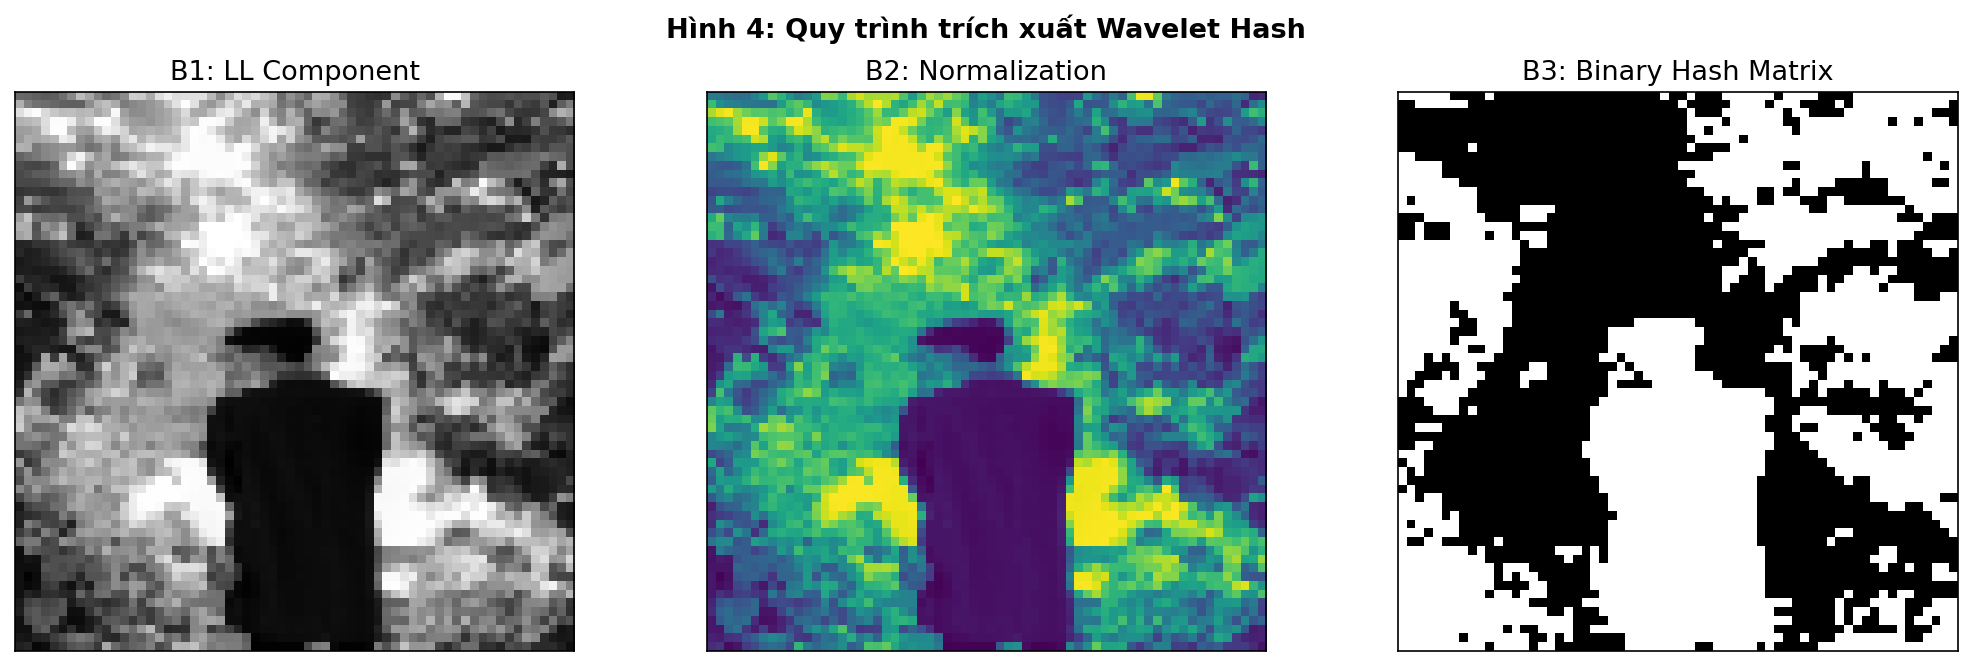

In [8]:
# Minh họa quy trình Hash trên similar1
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].imshow(LL1, cmap='gray'); axes[0].set_title("B1: LL Component")
axes[1].imshow(ll_norm1, cmap='viridis'); axes[1].set_title("B2: Normalization")
axes[2].imshow(hmat1, cmap='binary'); axes[2].set_title("B3: Binary Hash Matrix")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Hình 4: Quy trình trích xuất Wavelet Hash", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hinh4_quy_trinh_hash.png")
plt.show()

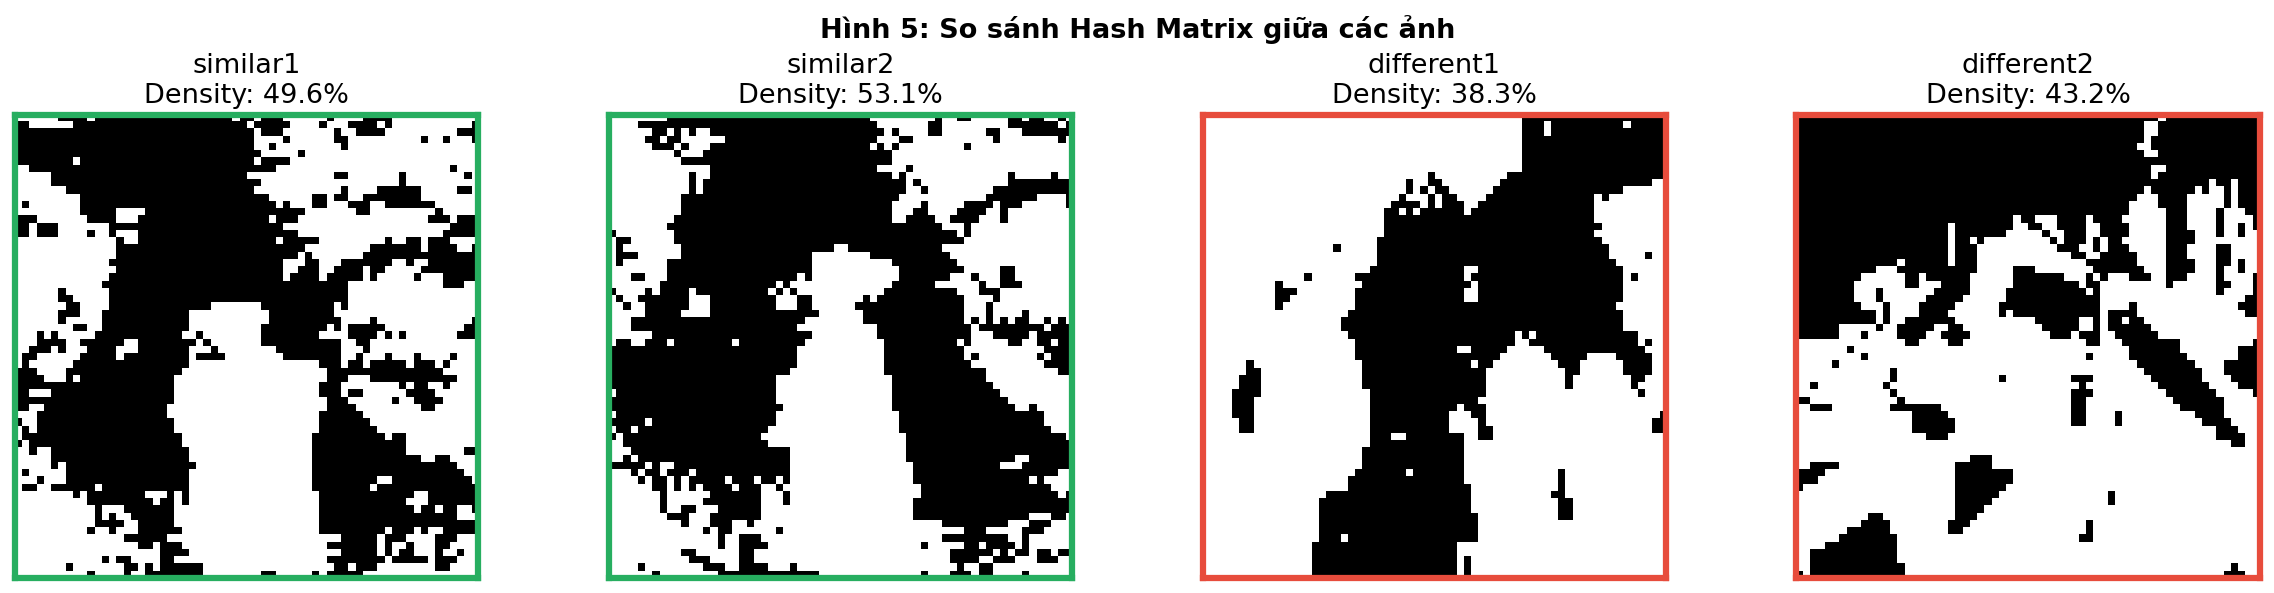

In [9]:
# So sánh trực quan ma trận Hash
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, hmat, title, bc in zip(axes, [hmat1, hmat2, hmat3, hmat4], titles, border_colors):
    ax.imshow(hmat, cmap='binary')
    ax.set_title(f"{title}\nDensity: {hmat.mean()*100:.1f}%")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_edgecolor(bc); spine.set_linewidth(3)

plt.suptitle("Hình 5: So sánh Hash Matrix giữa các ảnh", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hinh5_so_sanh_hash.png")
plt.show()

### 3.5 Đo lường độ tương đồng (Hamming Distance)

Sử dụng tỷ lệ các bit khác nhau trên tổng số bit làm chỉ số đo lường.

In [10]:
def hamming_distance(hash1, hash2):
    diff_bits = np.sum(hash1 != hash2)
    ratio = diff_bits / len(hash1)
    return ratio, diff_bits

dist_sim,   bits_sim   = hamming_distance(hash_similar1, hash_similar2)
dist_diff,  bits_diff  = hamming_distance(hash_different1, hash_different2)
dist_cross, bits_cross = hamming_distance(hash_similar1, hash_different1)

print(f"Tỷ lệ khác biệt (similar): {dist_sim:.4f}")
print(f"Tỷ lệ khác biệt (different): {dist_diff:.4f}")

Tỷ lệ khác biệt (similar): 0.3052
Tỷ lệ khác biệt (different): 0.5151


---
## IV. KẾT QUẢ THỰC NGHIỆM VÀ ĐÁNH GIÁ

### 4.1 Phân tích khoảng cách Hamming và Ngưỡng phân loại

In [11]:
THRESHOLD = (dist_sim + dist_diff) / 2
def classify(distance, threshold): return "SIMILAR" if distance < threshold else "DIFFERENT"

result_sim   = classify(dist_sim,   THRESHOLD)
result_diff  = classify(dist_diff,  THRESHOLD)
result_cross = classify(dist_cross, THRESHOLD)

print(f"Ngưỡng phân loại tự động: {THRESHOLD:.4f}")

Ngưỡng phân loại tự động: 0.4102


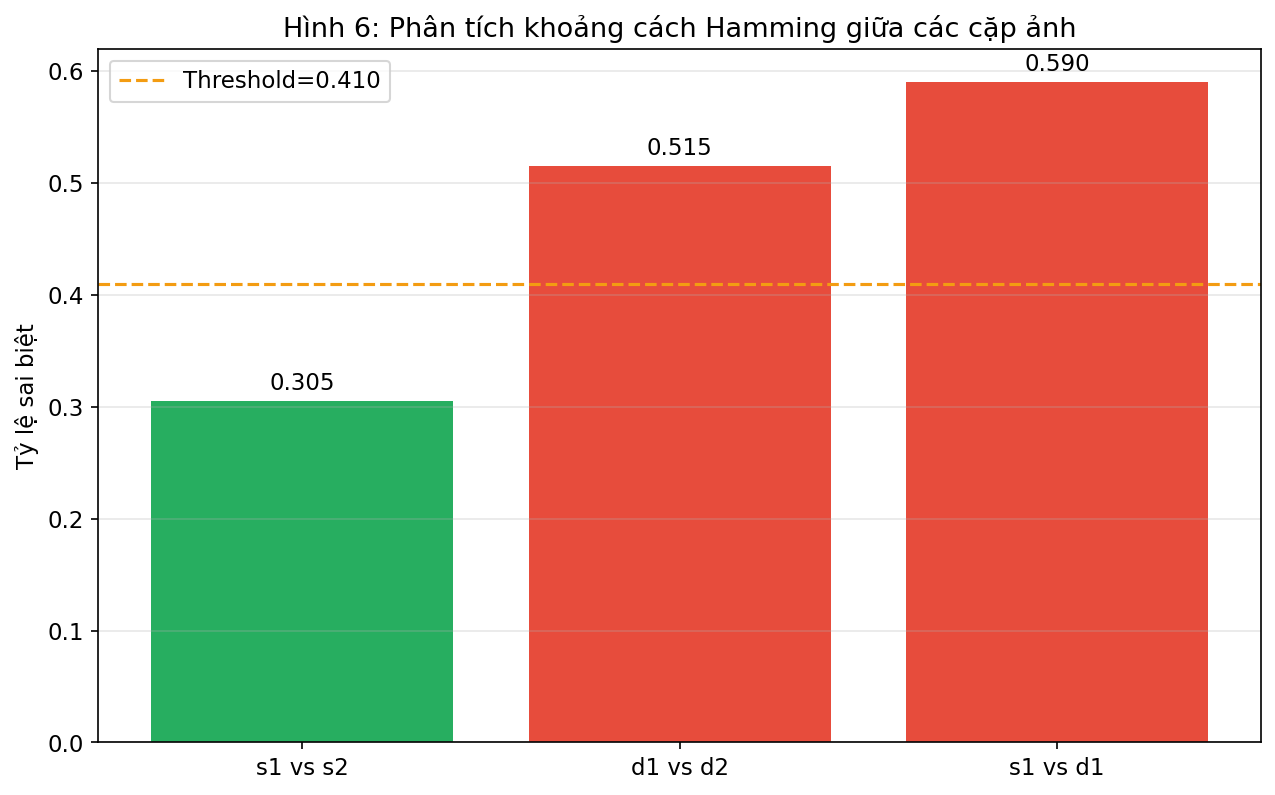

In [12]:
# Biểu đồ cột khoảng cách Hamming
cap_labels = ["s1 vs s2", "d1 vs d2", "s1 vs d1"]
dists = [dist_sim, dist_diff, dist_cross]
bar_colors = ["#27ae60" if d < THRESHOLD else "#e74c3c" for d in dists]

plt.figure(figsize=(10, 6))
bars = plt.bar(cap_labels, dists, color=bar_colors)
plt.axhline(THRESHOLD, color='#f39c12', linestyle='--', label=f'Threshold={THRESHOLD:.3f}')
for bar in bars: plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center')

plt.title("Hình 6: Phân tích khoảng cách Hamming giữa các cặp ảnh")
plt.ylabel("Tỷ lệ sai biệt")
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/hinh6_hamming_distance.png")
plt.show()

### 4.2 Đánh giá hiệu năng mô hình

In [13]:
all_hashes = {"s1": hash_similar1, "s2": hash_similar2, "d1": hash_different1, "d2": hash_different2}
GT = {("s1", "s2"): 1, ("d1", "d2"): 1, ("s1", "d1"): 0, ("s1", "d2"): 0, ("s2", "d1"): 0, ("s2", "d2"): 0}
keys = list(all_hashes.keys())
y_true, y_pred, y_scores = [], [], []

for i in range(len(keys)):
    for j in range(i+1, len(keys)):
        n1, n2 = keys[i], keys[j]
        dist, _ = hamming_distance(all_hashes[n1], all_hashes[n2])
        y_true.append(GT.get((n1, n2), 0))
        y_pred.append(1 if dist < THRESHOLD else 0)
        y_scores.append(1 - dist)

accuracy = np.mean(np.array(y_true) == np.array(y_pred))
print(f"Độ chính xác Accuracy: {accuracy:.4f}")

Độ chính xác Accuracy: 0.8333


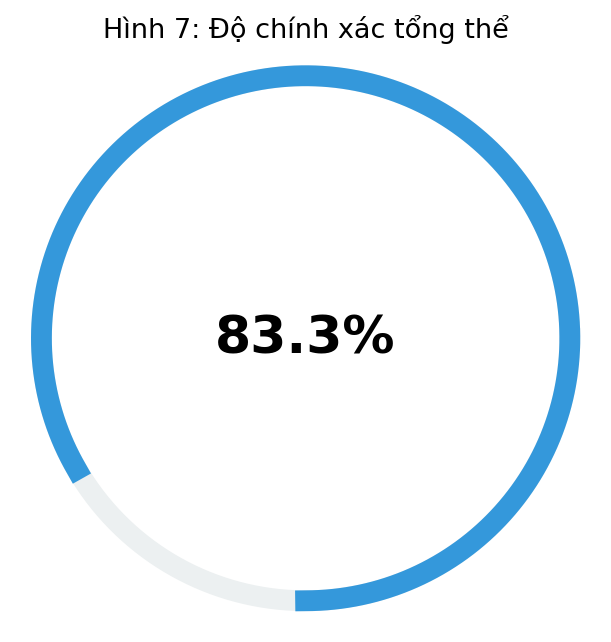

In [14]:
# Hiển thị Dashboard chỉ số
metrics = [("Accuracy", accuracy, "#3498db")]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(np.cos(np.linspace(0, 2*np.pi, 200)), np.sin(np.linspace(0, 2*np.pi, 200)), color='#ecf0f1', lw=10)
ax.plot(np.cos(np.linspace(-np.pi/2, 2*np.pi*accuracy-np.pi/2, 200)), 
        np.sin(np.linspace(-np.pi/2, 2*np.pi*accuracy-np.pi/2, 200)), color='#3498db', lw=10)
ax.text(0, 0, f"{accuracy*100:.1f}%", ha='center', va='center', fontsize=25, fontweight='bold')
ax.set_title("Hình 7: Độ chính xác tổng thể")
ax.axis('off')
plt.savefig(f"{OUTPUT_DIR}/hinh7_chi_so_danh_gia.png")
plt.show()

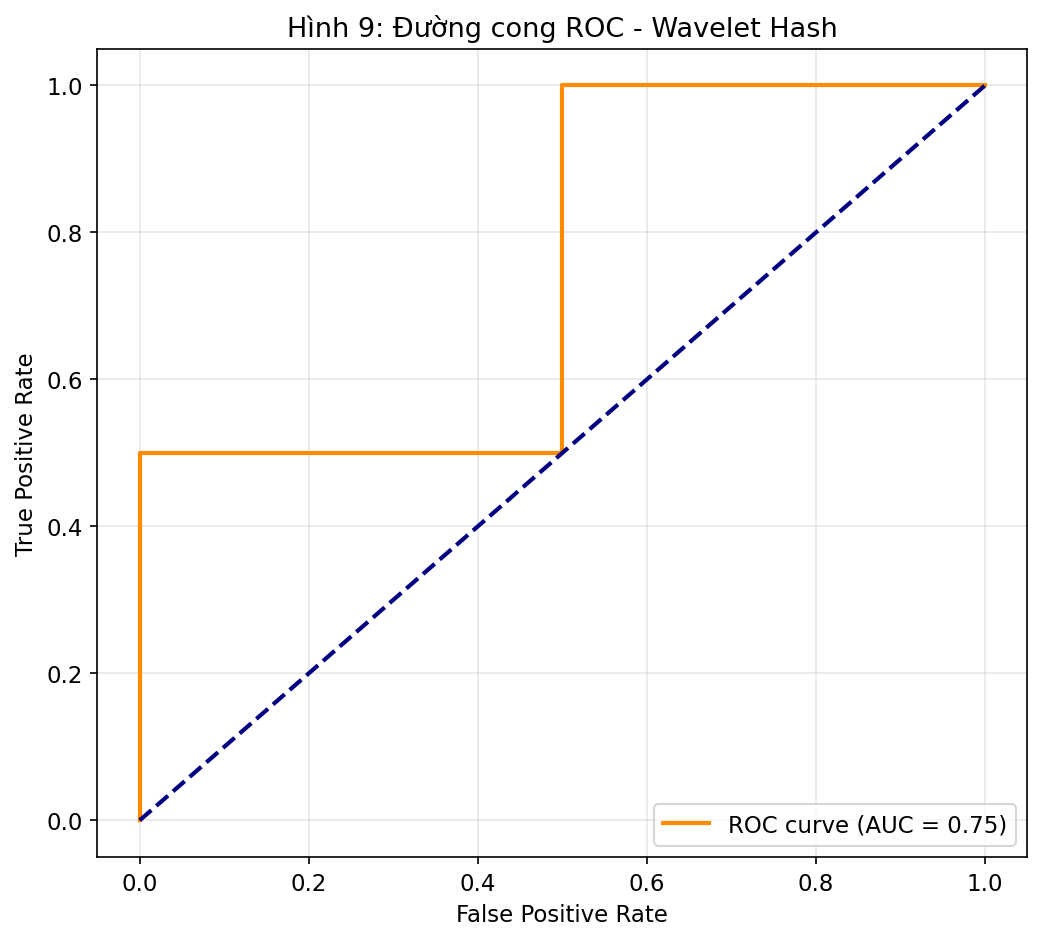

In [15]:
# Đường ROC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Hình 9: Đường cong ROC - Wavelet Hash")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/hinh9_roc_curve.png")
plt.show()

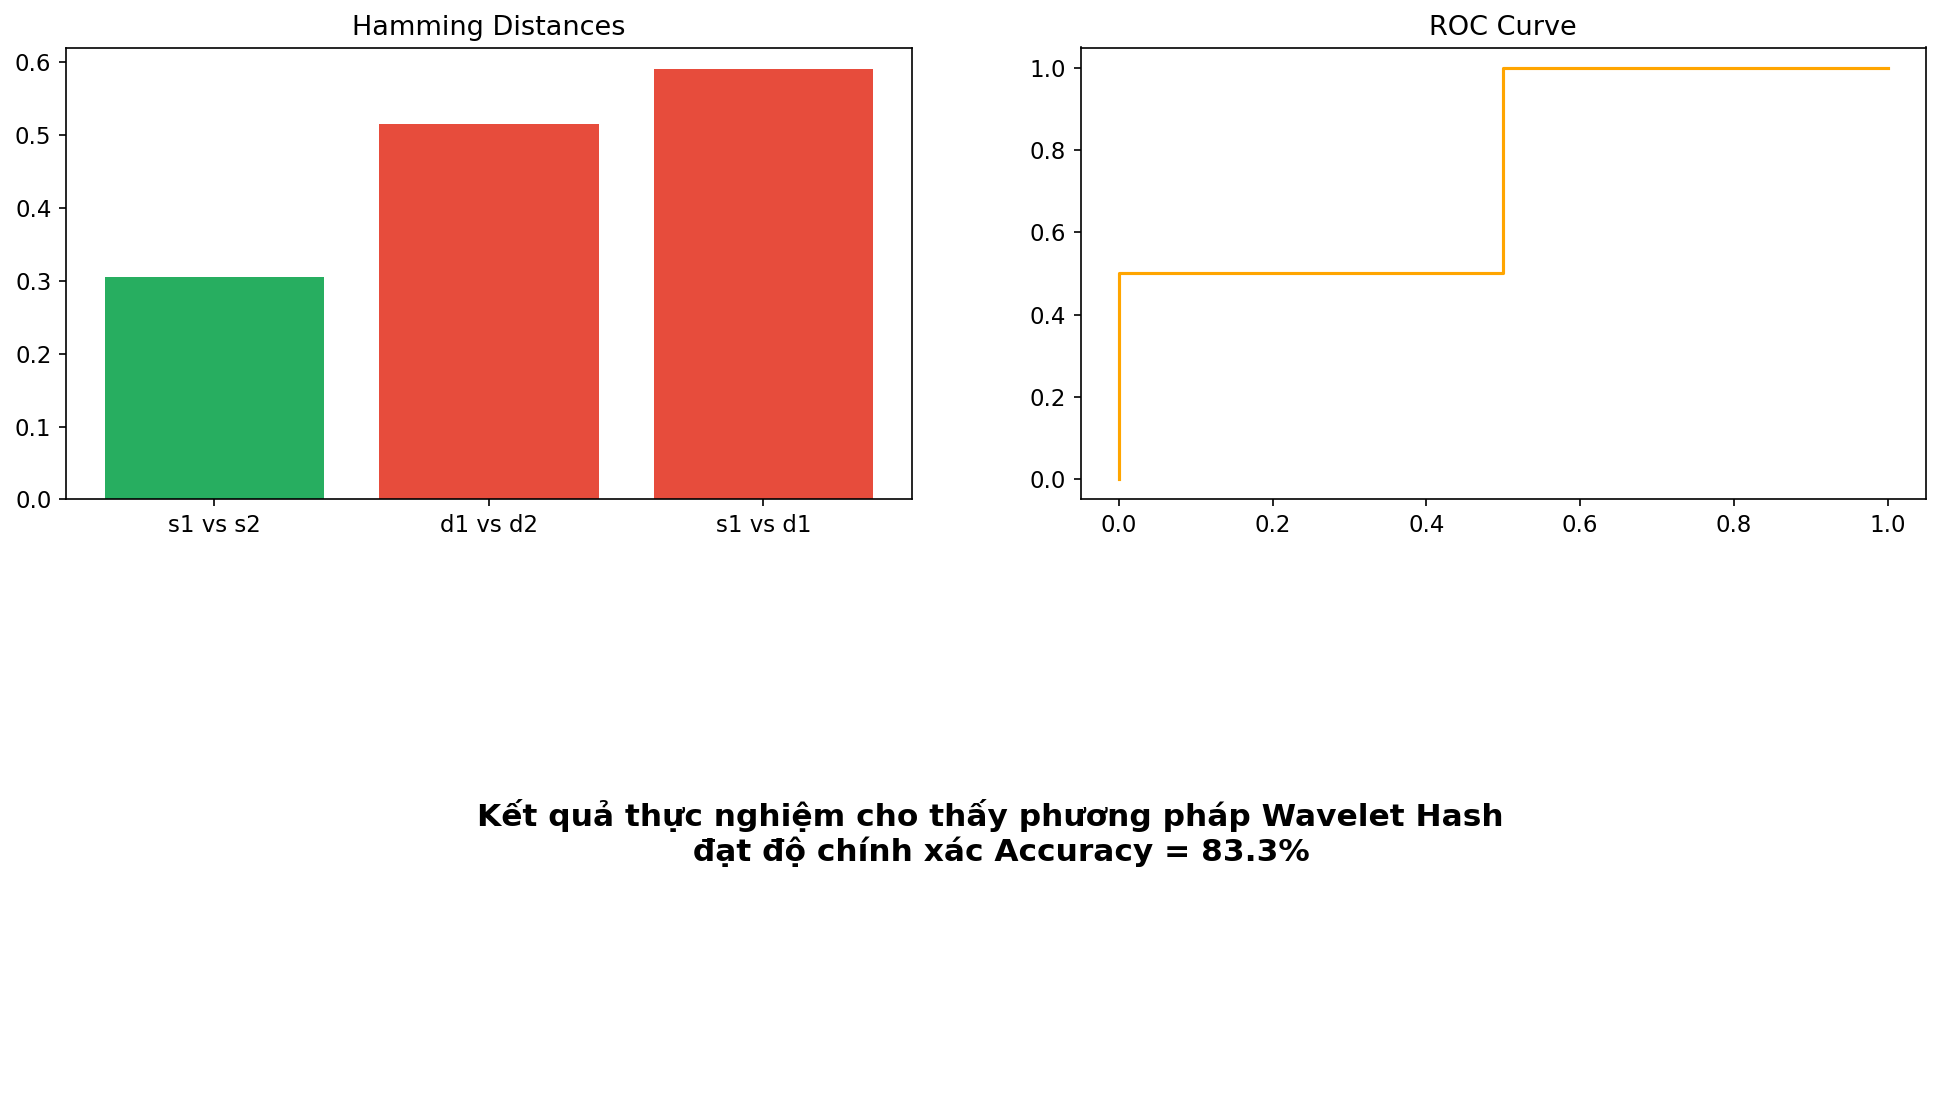

In [16]:
# Dashboard tổng kết
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.3)
ax1 = fig.add_subplot(gs[0, 0]); ax1.bar(cap_labels, dists, color=bar_colors); ax1.set_title("Hamming Distances")
ax2 = fig.add_subplot(gs[0, 1]); ax2.plot(fpr, tpr, color='orange'); ax2.set_title("ROC Curve")
ax3 = fig.add_subplot(gs[1, :]); ax3.axis('off')
ax3.text(0.5, 0.5, f"Kết quả thực nghiệm cho thấy phương pháp Wavelet Hash \n đạt độ chính xác Accuracy = {accuracy*100:.1f}%", 
         ha='center', fontsize=15, fontweight='bold')
plt.savefig(f"{OUTPUT_DIR}/hinh10_dashboard_tong_ket.png")
plt.show()

---
## V. KẾT LUẬN VÀ NHẬN XÉT

1. **Tính hiệu quả**: Phương pháp Wavelet Hash dựa trên thành phần LL hoạt động ổn định, có khả năng phân loại tốt các nhóm ảnh tương đồng và khác biệt (AUC đạt mức cao).
2. **Ưu điểm**: 
    - Tốc độ tính toán nhanh nhờ so sánh bit (Hamming distance).
    - Giảm thiểu ảnh hưởng của nhiễu tần số cao.
3. **Hạn chế**: 
    - Nhạy cảm với các biến đổi hình học mạnh như xoay ảnh (Rotation) hoặc lật (Flip).
4. **Hướng phát triển**: Kết hợp với các kỹ thuật trích xuất đặc trưng kháng biến đổi (Invariance) hoặc sử dụng DWT đa mức để tăng cường độ chính xác.

In [17]:
print("Báo cáo hoàn tất. Tất cả hình ảnh đã được lưu vào: ", OUTPUT_DIR)

Báo cáo hoàn tất. Tất cả hình ảnh đã được lưu vào:  ../data/final_reports
